# What Are TNG and Synthesizer?

Before we write real code in Notebooks 4 and 5, we need to understand the two big tools:

- **IllustrisTNG** — the cosmological simulation that produces the galaxy data
- **Synthesizer** — the software Sophie uses to turn that data into images and spectra

This notebook is mostly reading and interactive plots, but it sets up everything that follows.

In [ ]:
# Run this cell first — it installs everything you need.
# On COSMA or if packages are already installed this will be quick.

%pip install -q cosmos-synthesizer astropy h5py requests
print("All packages ready!")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

---

## Part 1 — IllustrisTNG: A Universe in a Box

### What is it?

**IllustrisTNG** (often just called 'TNG') is a series of cosmological simulations made by a team of researchers spread across Germany, the USA, and the UK. The name stands for *The Next Generation*.

The idea is bold: **simulate the entire history of the universe inside a computer**, starting just after the Big Bang and running forward 13.8 billion years to today.

### How does it work?

The simulation starts with conditions that match what we observe from the Cosmic Microwave Background (the 'afterglow' of the Big Bang). It then applies the laws of physics:

- **Gravity** pulls dark matter and gas together
- **Gas dynamics** — gas heats, cools, shocks, and flows
- **Star formation** — dense gas clouds collapse and form stars
- **Stellar feedback** — massive stars explode as supernovae, blowing gas away
- **Black holes** — massive ones form, accrete gas, and drive powerful winds
- **Chemical enrichment** — supernovae release heavy elements (oxygen, iron, etc.)

The simulation tracks all of this for **50 billion 'particles'** — tiny chunks of dark matter, gas, stars, and black holes.

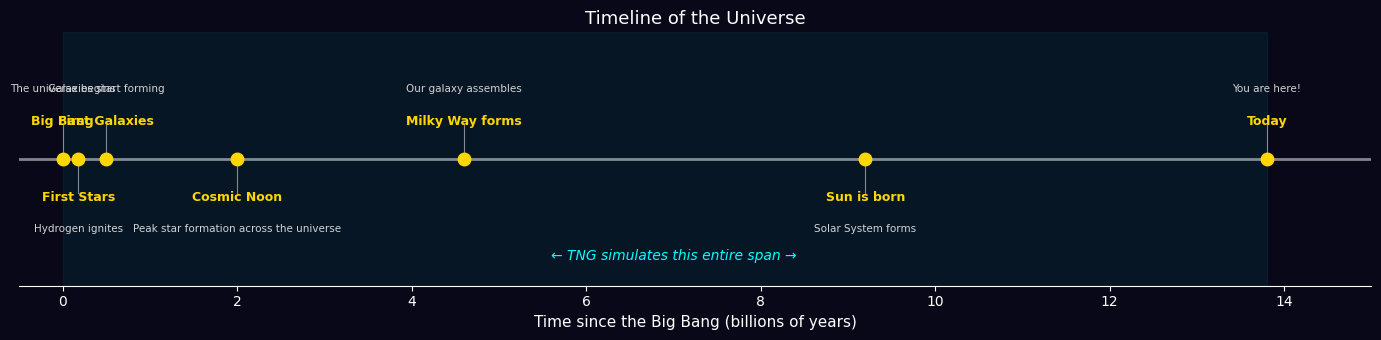

In [2]:
# Timeline of the Universe — and when TNG simulates

fig, ax = plt.subplots(figsize=(14, 3.5), facecolor='#080818')
ax.set_facecolor('#080818')

# Draw the time axis
ax.axhline(0, color='white', linewidth=2, alpha=0.5)

# Key events (time in Gyr)
events = [
    (0.0,   "Big Bang",         1,  "The universe begins"),
    (0.18,  "First Stars",      -1, "Hydrogen ignites"),
    (0.5,   "First Galaxies",   1,  "Galaxies start forming"),
    (2.0,   "Cosmic Noon",      -1, "Peak star formation across the universe"),
    (4.6,   "Milky Way forms",  1,  "Our galaxy assembles"),
    (9.2,   "Sun is born",      -1, "Solar System forms"),
    (13.8,  "Today",            1,  "You are here!"),
]

for t, name, side, desc in events:
    y_text = 0.6 * side
    y_desc = 1.1 * side
    ax.plot(t, 0, 'o', color='gold', markersize=9, zorder=5)
    ax.plot([t, t], [0, y_text * 0.9], color='white', lw=0.8, alpha=0.5)
    ax.text(t, y_text, name, color='gold', ha='center', va='center', fontsize=9, fontweight='bold')
    ax.text(t, y_desc, desc, color='lightgray', ha='center', va='center', fontsize=7.5)

# TNG simulation span
ax.axvspan(0, 13.8, alpha=0.06, color='cyan', zorder=0)
ax.text(7, -1.6, '← TNG simulates this entire span →', color='cyan',
        ha='center', fontsize=10, style='italic')

ax.set_xlim(-0.5, 15)
ax.set_ylim(-2, 2)
ax.set_xlabel('Time since the Big Bang (billions of years)', color='white', fontsize=11)
ax.set_title('Timeline of the Universe', color='white', fontsize=13)
ax.tick_params(colors='white', labeltop=False, top=False, left=False, right=False,
               labelleft=False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_color('white')
fig.patch.set_facecolor('#080818')
plt.tight_layout()
plt.show()

### The TNG Simulations — Different Sizes

There are three main TNG runs, each trading off **volume** against **resolution**:

| Name | Box side length | Number of particles | Typical galaxy |
|---|---|---|---|
| TNG300 | 300 Mpc (~1 billion light years) | 2 × 2500³ ≈ 30 billion | Massive galaxies & clusters |
| TNG100 | 100 Mpc (~330 million light years) | 2 × 1820³ ≈ 12 billion | All galaxy types |
| TNG50  | 50 Mpc (~160 million light years) | 2 × 2160³ ≈ 20 billion | **Best resolution** — individual stars & structure |

In Notebooks 4 and 5 we will use **TNG50** because it has beautiful high-resolution galaxy images.

A **megaparsec (Mpc)** is about 3.26 million light years. So TNG50 is a cube about 160 million light years on each side.

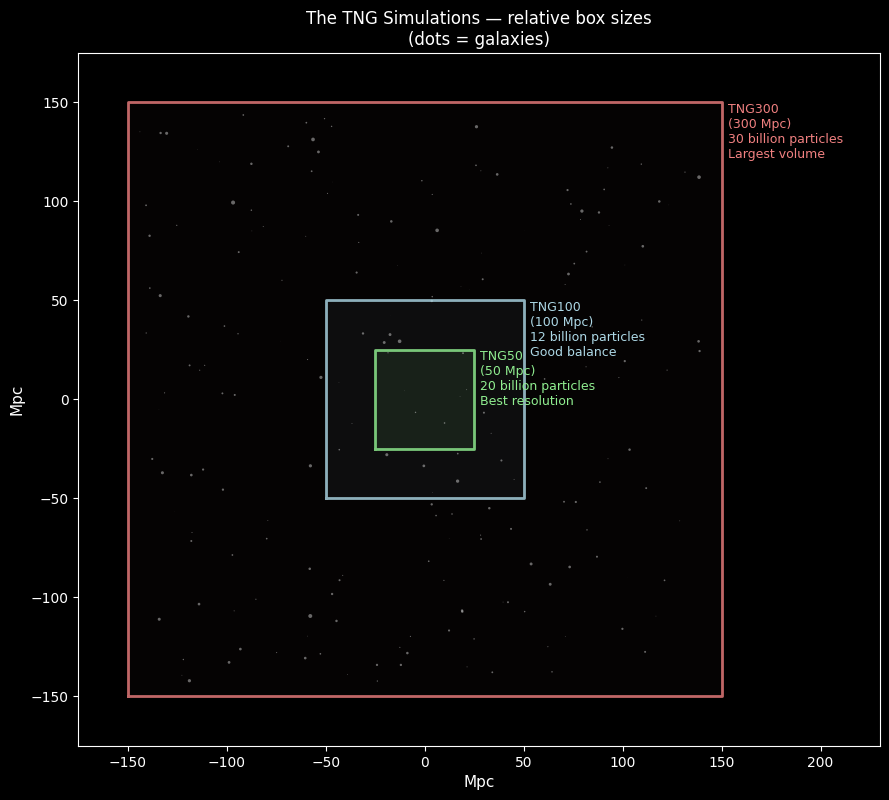

In [3]:
# Visualise the relative sizes of TNG simulations (in 2D cross-section)

fig, ax = plt.subplots(figsize=(9, 9), facecolor='black')
ax.set_facecolor('black')
ax.set_aspect('equal')

# Draw the three simulation boxes
boxes = [
    (300, 'TNG300', 'lightcoral',   '30 billion particles\nLargest volume', 0.15),
    (100, 'TNG100', 'lightblue',    '12 billion particles\nGood balance',   0.35),
    ( 50, 'TNG50',  'lightgreen',   '20 billion particles\nBest resolution', 0.6),
]

for size, name, colour, desc, alpha in boxes:
    rect = mpatches.FancyBboxPatch(
        (-size/2, -size/2), size, size,
        boxstyle="square,pad=0",
        linewidth=2, edgecolor=colour,
        facecolor=colour, alpha=alpha * 0.15
    )
    ax.add_patch(rect)
    ax.plot([-size/2, size/2, size/2, -size/2, -size/2],
            [-size/2, -size/2, size/2, size/2, -size/2],
            color=colour, linewidth=2, alpha=0.8)
    ax.text(size/2 + 3, size/2, f'{name}\n({size} Mpc)\n{desc}',
            color=colour, va='top', fontsize=9)

# Scatter some 'galaxies'
np.random.seed(10)
gx = np.random.uniform(-145, 145, 200)
gy = np.random.uniform(-145, 145, 200)
gs = np.random.exponential(2, 200)
ax.scatter(gx, gy, s=gs, c='white', alpha=0.4, linewidths=0)

ax.set_xlim(-175, 230)
ax.set_ylim(-175, 175)
ax.set_xlabel('Mpc', color='white', fontsize=11)
ax.set_ylabel('Mpc', color='white', fontsize=11)
ax.set_title('The TNG Simulations — relative box sizes\n(dots = galaxies)',
             color='white', fontsize=12)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('white')
fig.patch.set_facecolor('black')
plt.tight_layout()
plt.show()

---

## Part 2 — What Is Forward Modelling?

Here is the core challenge:

> **TNG gives us physical particles — positions, masses, ages, temperatures.**  
> **Telescopes measure light — brightness at different wavelengths.**

These are not the same thing. How do we compare a simulation to real observations?

The answer is **forward modelling**: take the simulation output and predict what a telescope *would* see if it observed that simulated galaxy.

```
  TNG simulation
  (physical properties)           Forward Model                  Synthetic observation
  ┌──────────────────┐            ┌──────────────┐               ┌────────────────────┐
  │ Star positions   │            │              │               │ Image in r-band    │
  │ Star masses      │  ────────► │  Synthesizer │  ──────────►  │ Image in UV        │
  │ Star ages        │            │              │               │ Spectrum           │
  │ Star metallicity │            │              │               │ Photometric colours│
  └──────────────────┘            └──────────────┘               └────────────────────┘
```

Once you have synthetic observations, you can directly compare them with **real telescope data** — does the simulation reproduce reality?

This is exactly what Sophie does. She forward-models TNG galaxies with Synthesizer and asks: *do the model galaxy colours and luminosities match what the Sloan Digital Sky Survey observes?*

In [4]:
# Demonstrate forward modelling with a toy example
# (Using simple models — the real thing happens in Notebook 4!)

# Imagine a galaxy with star particles of different ages
np.random.seed(15)
n_particles = 5000

ages_gyr     = np.random.exponential(3, n_particles)       # most stars are ~3 Gyr old
ages_gyr     = np.clip(ages_gyr, 0.01, 13)                 # keep in realistic range
masses_msun  = 10 ** np.random.normal(4, 0.5, n_particles) # particle masses
metallicity  = np.random.normal(0.01, 0.003, n_particles)  # fraction of metals

# The 'simulation output' — physical properties
print("=== Simulation gives us (physical properties) ===")
print(f"Number of star particles: {n_particles}")
print(f"Total stellar mass:       {masses_msun.sum():.2e} Msun")
print(f"Median stellar age:       {np.median(ages_gyr):.1f} Gyr")
print(f"Median metallicity:       {np.median(metallicity):.4f}")
print()

# Forward modelling: assign a spectrum to each particle based on age and metallicity
# (This is a SIMPLIFIED version — Synthesizer uses huge pre-computed grids!)
def particle_colour_index(age_gyr, metallicity):
    """
    A toy model: older, more metal-rich stars are redder.
    Returns a g-r colour (positive = redder, negative = bluer).
    """
    base_colour = 0.3 * np.log10(age_gyr + 0.1)  # older → redder
    metal_term  = 0.2 * np.log10(metallicity / 0.01 + 0.1)
    return base_colour + metal_term

# Compute colour for every particle — in real Synthesizer, this is a grid lookup
colours = particle_colour_index(ages_gyr, metallicity)

# Luminosity-weighted mean colour of the whole galaxy
luminosity_weight = masses_msun  # brighter particles contribute more
integrated_colour = np.average(colours, weights=luminosity_weight)

print("=== Forward model gives us (observable properties) ===")
print(f"Integrated g-r colour:    {integrated_colour:.3f} (positive = redder)")
if integrated_colour > 0.6:
    print("Classification: RED (quenched elliptical)")
elif integrated_colour > 0.3:
    print("Classification: GREEN (transition galaxy)")
else:
    print("Classification: BLUE (active star-forming spiral)")

=== Simulation gives us (physical properties) ===
Number of star particles: 5000
Total stellar mass:       9.81e+07 Msun
Median stellar age:       2.1 Gyr
Median metallicity:       0.0101

=== Forward model gives us (observable properties) ===
Integrated g-r colour:    nan (positive = redder)
Classification: BLUE (active star-forming spiral)


/tmp/ipykernel_165505/3083244164.py:29: RuntimeWarning: invalid value encountered in log10
  metal_term  = 0.2 * np.log10(metallicity / 0.01 + 0.1)


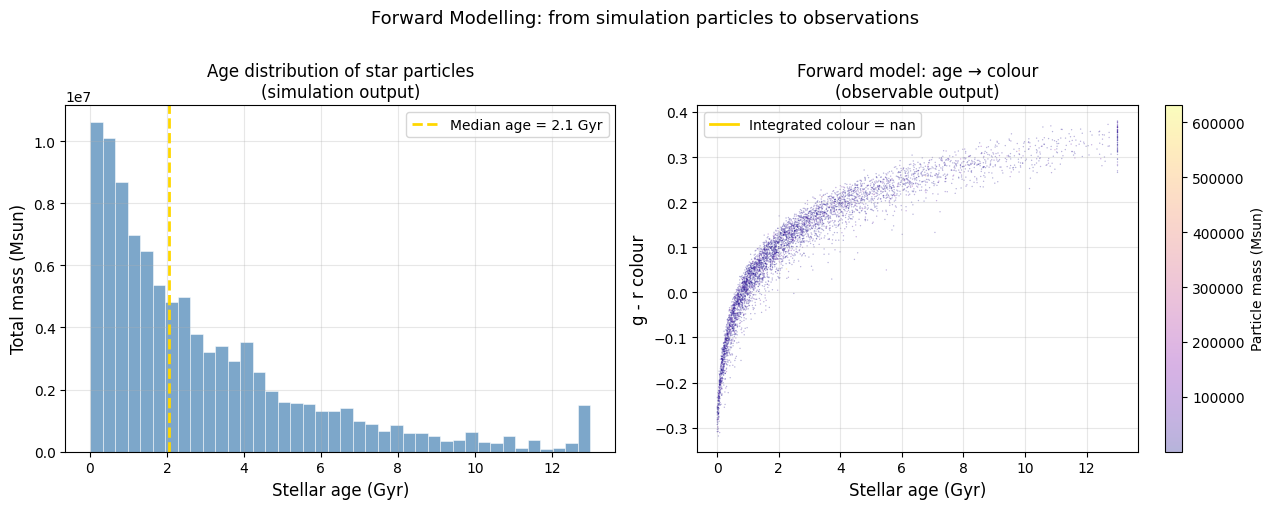

In [5]:
# Plot the particle age distribution and its effect on integrated colour

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: age histogram
axes[0].hist(ages_gyr, bins=40, weights=masses_msun,
             color='steelblue', alpha=0.7, edgecolor='white', linewidth=0.5)
axes[0].axvline(np.median(ages_gyr), color='gold', linewidth=2, linestyle='--',
               label=f'Median age = {np.median(ages_gyr):.1f} Gyr')
axes[0].set_xlabel('Stellar age (Gyr)', fontsize=12)
axes[0].set_ylabel('Total mass (Msun)', fontsize=12)
axes[0].set_title('Age distribution of star particles\n(simulation output)', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: age vs colour (the forward model)
sc = axes[1].scatter(ages_gyr, colours, c=masses_msun,
                     s=1, cmap='plasma', alpha=0.3, linewidths=0)
plt.colorbar(sc, ax=axes[1], label='Particle mass (Msun)')
axes[1].axhline(integrated_colour, color='gold', linewidth=2,
               label=f'Integrated colour = {integrated_colour:.2f}')
axes[1].set_xlabel('Stellar age (Gyr)', fontsize=12)
axes[1].set_ylabel('g - r colour', fontsize=12)
axes[1].set_title('Forward model: age → colour\n(observable output)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Forward Modelling: from simulation particles to observations",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---

## Part 3 — Synthesizer: The Software

### What is Synthesizer?

**Synthesizer** is an open-source Python package. It is designed to do exactly the forward modelling we just described — but properly, using full stellar physics.

### How does it work?

A key ingredient is a **Stellar Population Synthesis (SPS) grid** — a huge pre-computed table.

For every possible combination of:
- **Age** (e.g. 0.01 Gyr, 0.1 Gyr, 1 Gyr, 5 Gyr, ...)
- **Metallicity** (e.g. 0.0001, 0.001, 0.01, 0.1 × solar)

The grid stores: *what spectrum (light at every wavelength) does a population of stars with this age and metallicity emit?*

When Synthesizer processes a galaxy, it:
1. Looks up each star particle's age and metallicity in the grid
2. Reads off the particle's spectrum, scaled by its mass
3. Sums all the particle spectra → the total galaxy spectrum
4. Optionally applies **dust attenuation** (dust absorbs blue light more than red)
5. Folds through **telescope filter curves** → gives you the brightness a telescope would measure
6. Projects particles onto a 2D pixel grid → makes an **image**

In [ ]:
# The real SPS grid contains pre-computed spectra for thousands of (age, metallicity) combinations.
# You will see actual galaxy spectra computed from the real Maraston grid in Notebook 4!

print("SPS grid key points:")
print("  • Younger stellar populations → peak emission at shorter (UV) wavelengths")
print("  • Older stellar populations   → peak emission at longer (infrared) wavelengths")
print("  • Higher metallicity          → slightly redder spectrum overall")
print()
print("→ You will see the real Maraston SPS spectra in Notebook 4!")

---

## Part 4 — What Does Dust Do?

**Interstellar dust** — tiny grains of carbon and silicate — sits between and around stars inside galaxies. Dust has a big effect on what we observe:

- It **absorbs** light, making galaxies appear fainter
- It absorbs **blue/UV light more than red/infrared light** — this is called *reddening*
- The absorbed energy is re-emitted at long infrared wavelengths

This means that if you ignore dust, you will overestimate how many new stars a galaxy is forming (because the UV light that new stars produce is hidden by dust).

Modelling dust is a major part of Sophie's research.

In [ ]:
# Dust attenuation key points — you will see this applied to a real galaxy spectrum in Notebook 5:
#   • UV photons are absorbed most efficiently by dust grains
#   • The Calzetti law is a common empirical dust model, calibrated on real starburst galaxies
#   • A_V = 1 mag means roughly 60% of V-band (5500 Å) light is absorbed

print("Dust attenuation key points:")
print("  • Dust absorbs UV light far more strongly than infrared light")
print("  • A galaxy full of young blue stars can look red if it has lots of dust")
print("  • A_V = 1 mag ≈ 60% of visible light absorbed; much more UV absorbed")
print()
print("→ You will apply dust attenuation to a real TNG galaxy spectrum in Notebook 5!")

---

## Summary

You now know:

- **IllustrisTNG** simulates the formation of galaxies from the Big Bang to today, tracking ~50 billion particles
- **Forward modelling** converts simulation physics (particle positions, ages, metallicities) into predicted observations (spectra, images)
- **Synthesizer** does this conversion using a pre-computed SPS grid of stellar spectra
- **Dust** absorbs blue light preferentially, reddening and dimming galaxies

In the next notebook, you will actually **run Synthesizer on real TNG data** and produce your own galaxy images.

---

### A quick look at the software you'll use

Before you go, run this cell to check that Synthesizer is installed correctly:

In [9]:
# Check everything is installed
import importlib, sys

packages = {
    "synthesizer":  "Synthesizer — galaxy modelling",
    "astropy":       "Astropy — astronomical tools",
    "h5py":          "h5py — read simulation HDF5 files",
    "requests":      "requests — download data from the internet",
    "numpy":         "NumPy — fast numerical arrays",
    "matplotlib":    "Matplotlib — plotting",
}

all_ok = True
for pkg, description in packages.items():
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, '__version__', 'installed')
        print(f"  OK  {description} (v{ver})")
    except ImportError:
        print(f"  MISSING  {description}")
        print(f"           Run: pip install {pkg}")
        all_ok = False

print()
if all_ok:
    print("Everything is installed — you are ready for Notebook 4!")
else:
    print("Some packages are missing. See the README for installation instructions.")
    print("Ask Sophie for help if you get stuck.")

  OK  Synthesizer — galaxy modelling (v1.0.2.dev87+g80e71ae89)
  OK  Astropy — astronomical tools (v5.3.4)
  OK  h5py — read simulation HDF5 files (v3.10.0)
  OK  requests — download data from the internet (v2.32.3)
  OK  NumPy — fast numerical arrays (v1.26.4)
  OK  Matplotlib — plotting (v3.8.2)

Everything is installed — you are ready for Notebook 4!


**→ Open `04_galaxy_images.ipynb` — time to make real galaxy images!**